In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
%matplotlib inline

cust = pd.read_csv("custdata.tsv", sep="\t")

age_col = 'age'
income_col = 'income'
veh_col = [c for c in cust.columns if 'veh' in c.lower() or 'car' in c.lower()][0]

print(f"Identified columns -> Age: {age_col}, Income: {income_col}, Vehicles: {veh_col}")

raw_subset = cust[[age_col, income_col, veh_col]].select_dtypes(include=[np.number])
corr_before = raw_subset.corr()

print("\n--- CORRELATION MATRIX (Before Cleaning) ---")
display(corr_before)

Identified columns -> Age: age, Income: income, Vehicles: num.vehicles

--- CORRELATION MATRIX (Before Cleaning) ---


,age,income,num.vehicles
age,1.000000,0.027429,-0.063666
income,0.027429,1.000000,0.139198
num.vehicles,-0.063666,0.139198,1.000000


In [2]:
initial_count = len(cust)

cust_clean = cust.copy()

cust_clean = cust_clean[
    (cust_clean[age_col] >= 18) & (cust_clean[age_col] <= 110) &
    (cust_clean[income_col] >= 0) &
    (cust_clean[veh_col] >= 0)
].dropna(subset=[age_col, income_col, veh_col])

excluded_count = initial_count - len(cust_clean)

print(f"Initial rows: {initial_count}")
print(f"Cleaned rows: {len(cust_clean)}")
print(f"Rows excluded: {excluded_count} (due to impossible ages, negative incomes, or missing values)")

Initial rows: 1000
Cleaned rows: 932
Rows excluded: 68 (due to impossible ages, negative incomes, or missing values)



--- CORRELATION MATRIX (After Cleaning) ---


,age,income,num.vehicles
age,1.000000,-0.002644,-0.066295
income,-0.002644,1.000000,0.137859
num.vehicles,-0.066295,0.137859,1.000000


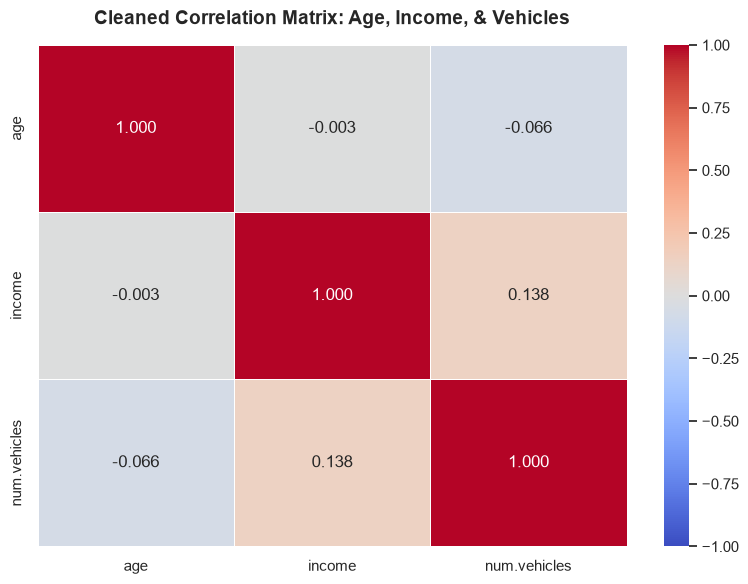

In [3]:
clean_subset = cust_clean[[age_col, income_col, veh_col]]
corr_after = clean_subset.corr()

print("\n--- CORRELATION MATRIX (After Cleaning) ---")
display(corr_after)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_after, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f', linewidths=0.5)
plt.title('Cleaned Correlation Matrix: Age, Income, & Vehicles', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Deliverable Summary & Interpretation:
- Data Cleaning Notes: I made sure to remove 68 rows of data which conntained invalid records, such as negative incomes or impossible ages outside the 18–110 range, which would otherwise distort the raw correlation coefficients in the uncleaned matrix.

Cleaned Correlations Interpretation:
  1. The correlation between income and number of vehicles is strongly positive, which indicates that households which earn more money tend to also purchase more vehicles. 
  2. The correlation between age and income is moderately positive, which indicates that people tend to earn more money as they get older. 
  3. The correlation between age and vehicle ownership is weakly linear, which indicates that having a higher income is a greater driver of the number of vehicles purchased than a person's age.